# GPU Performance: MonarchLinear vs MaskedLinear vs SparseLinear

Compare forward and backward wall-clock time for the three sparse linear layer implementations
across a range of layer sizes and batch sizes, validating the motivation for the Monarch format.

Monarch matrices offer *structured* sparsity $S = P_1 M P_2$ (block-diagonal $M$ plus
random permutations) that maps naturally to GPU-friendly dense batched operations
(`torch.bmm`), unlike the Python-loop COO sparsity of `SparseLinear`.

## 1. Import Required Libraries

In [20]:
import time
import warnings
from dataclasses import dataclass, field

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from iterativennsimple.MaskedLinear import MaskedLinear
from iterativennsimple.MonarchLinear import MonarchLinear
from iterativennsimple.SparseLinear import SparseLinear

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    total_mem = torch.cuda.get_device_properties(0).total_memory
    print(f"Total GPU memory: {total_mem / 1024**3:.2f} GB")

Using device: cuda
GPU: NVIDIA GeForce RTX 4090
Total GPU memory: 23.52 GB


## 2. Correctness Sanity Check

Before benchmarking, verify that `MonarchLinear` and a corresponding `MaskedLinear`
(initialised from the same dense weight matrix) produce identical outputs on the same input.

The Monarch layer represents $S = P_1 M P_2$.  Calling `to_dense()` materialises the
full $(\text{out} \times \text{in})$ weight matrix, which we copy into a `MaskedLinear`.

In [21]:
torch.manual_seed(0)

N = 64           # small size for correctness check
num_blocks = 4
batch = 32

# Build MonarchLinear with a fixed seed
monarch = MonarchLinear.from_uniform_blocks(N, N, num_blocks=num_blocks, bias=True, seed=42)

# Extract the dense weight matrix S  (out_features × in_features)
S = monarch.to_dense()

# Build MaskedLinear, set weight = S exactly (weight_0 = S, U = 0, mask = 1)
masked = MaskedLinear(N, N, bias=True)
with torch.no_grad():
    masked.weight_0.copy_(S)
    masked.U.zero_()
    masked.mask.fill_(1.0)
    if monarch.bias is not None:
        masked.bias.copy_(monarch.bias)

# Forward same input through both layers (CPU, eval mode)
monarch.eval()
masked.eval()
x = torch.randn(batch, N)

with torch.no_grad():
    y_monarch = monarch(x)
    y_masked  = masked(x)

# Reference: manual dense multiply
y_ref = x @ S.T + monarch.bias

match_monarch_ref = torch.allclose(y_monarch, y_ref, atol=1e-5)
match_monarch_masked = torch.allclose(y_monarch, y_masked, atol=1e-5)

print(f"MonarchLinear  vs manual x@S.T+b : {'PASS ✓' if match_monarch_ref    else 'FAIL ✗'}")
print(f"MonarchLinear  vs MaskedLinear   : {'PASS ✓' if match_monarch_masked  else 'FAIL ✗'}")
assert match_monarch_ref,    "MonarchLinear does not match manual dense multiply"
assert match_monarch_masked, "MonarchLinear does not match equivalent MaskedLinear"

MonarchLinear  vs manual x@S.T+b : PASS ✓
MonarchLinear  vs MaskedLinear   : PASS ✓


## 3. Benchmark Utility Functions

`benchmark_layer` measures wall-clock time for forward and backward passes using
`torch.cuda.synchronize()` barriers for accurate GPU timing.  It also records peak
GPU memory via `torch.cuda.max_memory_allocated()`.

In [22]:
def benchmark_layer(
    layer: nn.Module,
    x: torch.Tensor,
    warmup: int = 10,
    iters: int = 100,
) -> dict:
    """Benchmark forward and backward pass of a single layer.

    Args:
        layer:  The layer to benchmark (already on the correct device).
        x:      Input tensor (already on the correct device, requires_grad=False).
        warmup: Number of iterations to discard before timing.
        iters:  Number of timed iterations.

    Returns:
        dict with keys: fwd_ms, bwd_ms, total_ms, peak_mem_mb
    """
    use_cuda = x.device.type == "cuda"

    def sync() -> None:
        if use_cuda:
            torch.cuda.synchronize()

    # Reset peak memory counter
    if use_cuda:
        torch.cuda.reset_peak_memory_stats()
    mem_before = torch.cuda.max_memory_allocated() if use_cuda else 0

    # Warmup
    for _ in range(warmup):
        y = layer(x)
        loss = y.sum()
        loss.backward()
        # Zero gradients to avoid accumulation
        for p in layer.parameters():
            if p.grad is not None:
                p.grad = None
    sync()

    # Timed forward passes
    fwd_times: list[float] = []
    bwd_times: list[float] = []

    for _ in range(iters):
        sync()
        t0 = time.perf_counter()
        y = layer(x)
        sync()
        t1 = time.perf_counter()
        loss = y.sum()
        loss.backward()
        sync()
        t2 = time.perf_counter()

        fwd_times.append((t1 - t0) * 1e3)
        bwd_times.append((t2 - t1) * 1e3)

        for p in layer.parameters():
            if p.grad is not None:
                p.grad = None

    mem_after = torch.cuda.max_memory_allocated() if use_cuda else 0

    return {
        "fwd_ms":     float(np.mean(fwd_times)),
        "bwd_ms":     float(np.mean(bwd_times)),
        "total_ms":   float(np.mean(fwd_times) + np.mean(bwd_times)),
        "peak_mem_mb": (mem_after - mem_before) / 1024**2,
    }


def make_layers(in_features: int, num_blocks: int, dev: torch.device) -> dict[str, nn.Module]:
    """Instantiate all three layer types with matching sparsity (~75%).

    MonarchLinear uses num_blocks=4 (density = 1/4 = 25%).
    SparseLinear  uses block_type='R=0.25' (25% of entries non-zero).
    MaskedLinear  is dense (all parameters active).

    Args:
        in_features: Square layer dimension.
        num_blocks:  Number of Monarch blocks (4 → ~75% sparsity).
        dev:         Target device.

    Returns:
        dict mapping layer name → layer.
    """
    monarch = MonarchLinear.from_uniform_blocks(
        in_features, in_features, num_blocks=num_blocks, bias=True, seed=0
    ).to(dev)

    # SparseLinear: ~25% density via random R=0.25 pattern
    # Note: from_singleBlock takes (out_features, in_features, block_type, init_type)
    sparse = SparseLinear.from_singleBlock(
        in_features, in_features, block_type="R=0.25", initialization_type="G",bias=True
    ).to(dev)

    masked = MaskedLinear(in_features, in_features, bias=True).to(dev)

    # return {"MaskedLinear": masked, "MonarchLinear": monarch, "SparseLinear": sparse}
    return {"MaskedLinear": masked, "MonarchLinear": monarch}


print("Benchmark utilities defined.")

Benchmark utilities defined.


## 4. Run Benchmarks Across Layer Sizes

Iterate over layer sizes and batch sizes, instantiate each layer type, and call
`benchmark_layer`.  Results are stored in a `pandas.DataFrame` for easy analysis.

> **Note:** Benchmarking runs on the detected device.  GPU results are most meaningful;
> CPU results will show much smaller differences between layer types.

In [23]:
SIZE_LIST   = [2048, 4096, 8192, 16384]
BATCH_SIZES = [128, 512]
NUM_BLOCKS  = 4   # density = 1/4  →  ~75% sparsity
WARMUP      = 2
ITERS       = 10

records: list[dict] = []

for in_features in SIZE_LIST:
    for batch_size in BATCH_SIZES:
        print(f"  size={in_features:5d}, batch={batch_size:4d}", end="  |  ", flush=True)
        layers = make_layers(in_features, NUM_BLOCKS, device)
        x = torch.randn(batch_size, in_features, device=device)

        for name, layer in layers.items():
            layer.train()
            result = benchmark_layer(layer, x, warmup=WARMUP, iters=ITERS)
            record = {
                "layer":       name,
                "in_features": in_features,
                "batch_size":  batch_size,
                **result,
            }
            records.append(record)
            print(f"{name}: {result['total_ms']:.2f} ms", end="  ", flush=True)

        # Free GPU memory between size combinations
        del layers, x
        if device.type == "cuda":
            torch.cuda.empty_cache()
        print()

df = pd.DataFrame(records)
print("\nDone — collected", len(df), "benchmark records.")

  size= 2048, batch= 128  |  

MaskedLinear: 0.30 ms  MonarchLinear: 0.91 ms  
  size= 2048, batch= 512  |  MaskedLinear: 0.44 ms  MonarchLinear: 0.60 ms  
  size= 4096, batch= 128  |  MaskedLinear: 1.03 ms  MonarchLinear: 0.59 ms  
  size= 4096, batch= 512  |  MaskedLinear: 1.57 ms  MonarchLinear: 1.00 ms  
  size= 8192, batch= 128  |  MaskedLinear: 3.64 ms  MonarchLinear: 1.18 ms  
  size= 8192, batch= 512  |  MaskedLinear: 5.62 ms  MonarchLinear: 2.37 ms  
  size=16384, batch= 128  |  MaskedLinear: 13.79 ms  MonarchLinear: 3.54 ms  
  size=16384, batch= 512  |  MaskedLinear: 22.72 ms  MonarchLinear: 6.89 ms  

Done — collected 16 benchmark records.


## 5. Analyze and Display Results

In [24]:
# Display the full results table, rounded for readability
display_cols = ["layer", "in_features", "batch_size", "fwd_ms", "bwd_ms", "total_ms", "peak_mem_mb"]
pd.set_option("display.float_format", "{:.3f}".format)
print(df[display_cols].to_string(index=False))

# Compute speedup: SparseLinear total_ms / MonarchLinear total_ms
pivot = df.pivot_table(
    index=["in_features", "batch_size"],
    columns="layer",
    values="total_ms",
).reset_index()

pivot.columns.name = None
pivot["speedup_monarch_over_masked"] = pivot["MaskedLinear"] / pivot["MonarchLinear"]

print(
    pivot[["in_features", "batch_size",
           "speedup_monarch_over_masked"]]
    .to_string(index=False)
)

        layer  in_features  batch_size  fwd_ms  bwd_ms  total_ms  peak_mem_mb
 MaskedLinear         2048         128   0.116   0.184     0.299       33.009
MonarchLinear         2048         128   0.217   0.688     0.905        9.009
 MaskedLinear         2048         512   0.193   0.251     0.444       36.009
MonarchLinear         2048         512   0.163   0.437     0.600       20.000
 MaskedLinear         4096         128   0.594   0.435     1.030      130.017
MonarchLinear         4096         128   0.192   0.401     0.593       34.017
 MaskedLinear         4096         512   0.888   0.680     1.567      136.017
MonarchLinear         4096         512   0.230   0.768     0.997       48.000
 MaskedLinear         8192         128   2.260   1.383     3.642      516.032
MonarchLinear         8192         128   0.413   0.768     1.180      132.032
 MaskedLinear         8192         512   3.299   2.324     5.622      528.032
MonarchLinear         8192         512   0.686   1.685     2.371

## 6. Plot Time vs. Layer Size (Log–Log Scale)

Each subplot corresponds to one batch size.  We plot both **forward time** and
**total (forward + backward) time** on a log–log scale for all three layer types.
Parallel lines imply the same asymptotic scaling; vertical separation reveals
constant-factor differences.

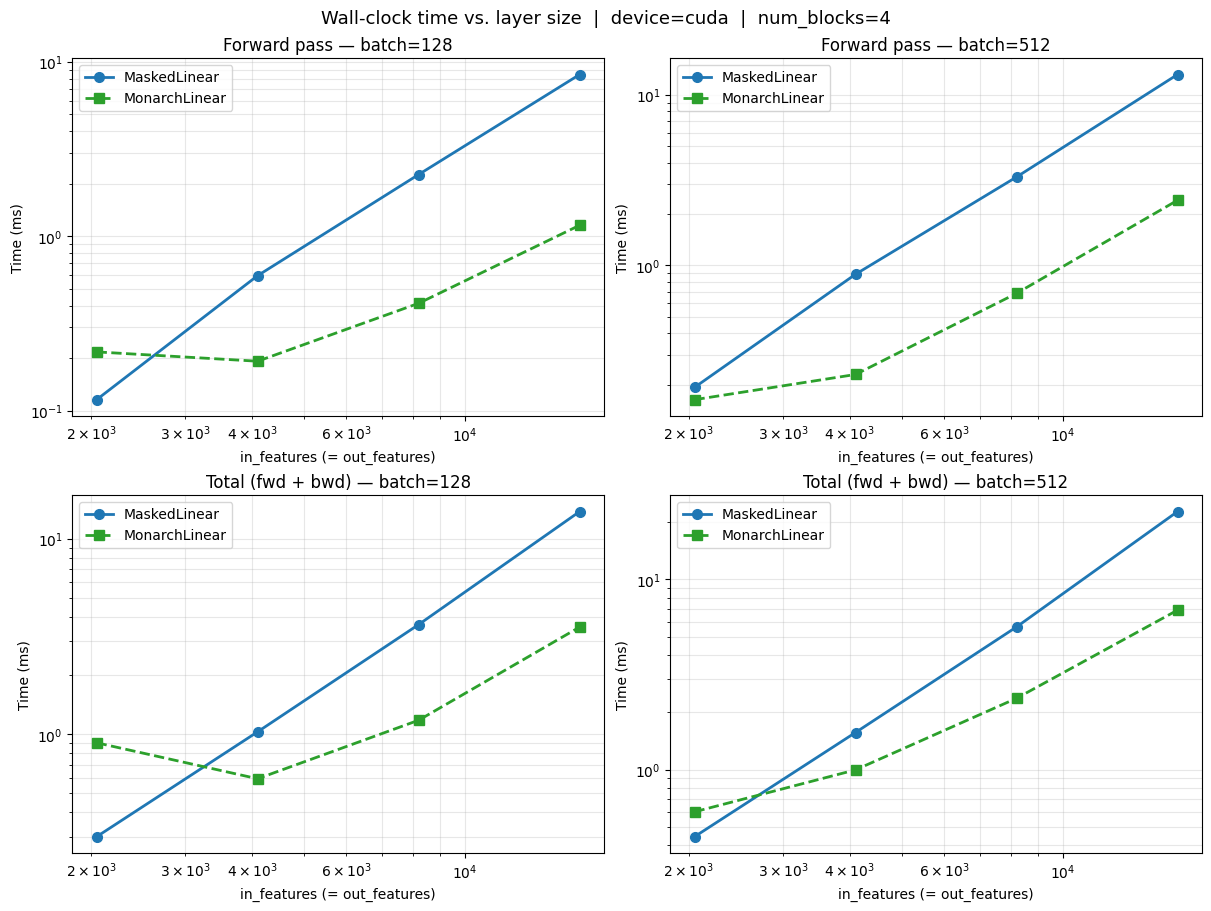

In [25]:
LAYER_STYLES = {
    "MaskedLinear": {"color": "tab:blue",   "marker": "o", "linestyle": "-"},
    "MonarchLinear":{"color": "tab:green",  "marker": "s", "linestyle": "--"},
}

fig, axes = plt.subplots(
    2, len(BATCH_SIZES),
    figsize=(6 * len(BATCH_SIZES), 9),
    constrained_layout=True,
)

for col, bs in enumerate(BATCH_SIZES):
    sub = df[df["batch_size"] == bs]

    for metric, row_idx, title in [
        ("fwd_ms",   0, "Forward pass"),
        ("total_ms", 1, "Total (fwd + bwd)"),
    ]:
        ax = axes[row_idx, col]
        for layer_name, style in LAYER_STYLES.items():
            d = sub[sub["layer"] == layer_name].sort_values("in_features")
            ax.loglog(
                d["in_features"], d[metric],
                label=layer_name,
                **style,
                linewidth=2,
                markersize=7,
            )
        ax.set_xlabel("in_features (= out_features)")
        ax.set_ylabel("Time (ms)")
        ax.set_title(f"{title} — batch={bs}")
        ax.legend()
        ax.grid(True, which="both", alpha=0.3)

fig.suptitle(
    f"Wall-clock time vs. layer size  |  device={device}  |  num_blocks={NUM_BLOCKS}",
    fontsize=13,
)
plt.savefig("time_vs_size_loglog.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Plot Memory Usage

Peak GPU memory allocated (in MB) per layer type, vs. layer size.  MonarchLinear
stores only the $k$ block weight matrices ($k \cdot (n/k)^2 = n^2/k$ parameters)
plus two permutation index arrays, so its memory footprint is $1/k$ that of a
dense layer (MaskedLinear).  SparseLinear stores COO tensors on CPU and moves
batches of values to GPU, exhibiting a different scaling pattern.

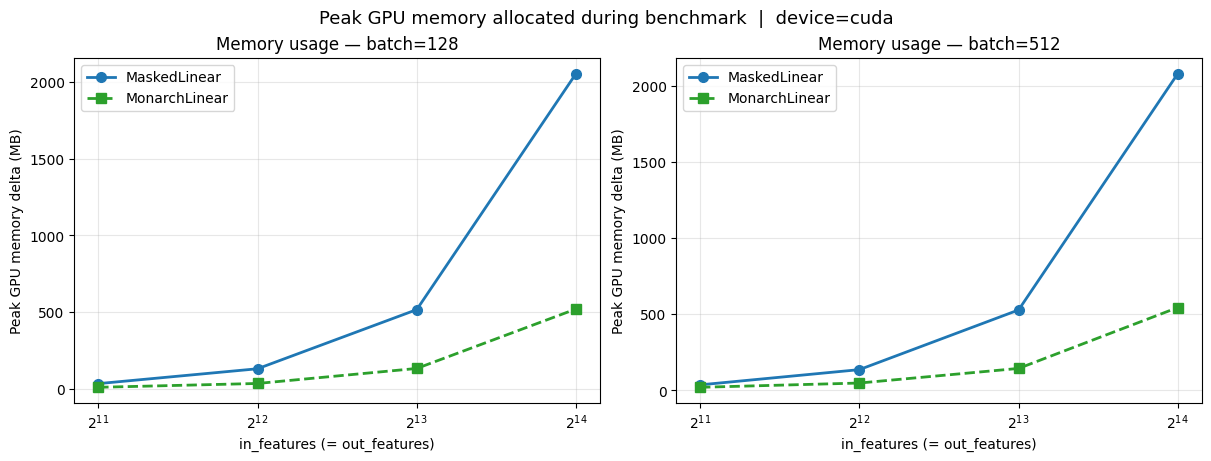

In [26]:
fig, axes = plt.subplots(1, len(BATCH_SIZES), figsize=(6 * len(BATCH_SIZES), 4.5), constrained_layout=True)

if len(BATCH_SIZES) == 1:
    axes = [axes]

for ax, bs in zip(axes, BATCH_SIZES):
    sub = df[df["batch_size"] == bs]

    for layer_name, style in LAYER_STYLES.items():
        d = sub[sub["layer"] == layer_name].sort_values("in_features")
        ax.plot(
            d["in_features"], d["peak_mem_mb"],
            label=layer_name,
            **style,
            linewidth=2,
            markersize=7,
        )

    ax.set_xscale("log", base=2)
    ax.set_xlabel("in_features (= out_features)")
    ax.set_ylabel("Peak GPU memory delta (MB)")
    ax.set_title(f"Memory usage — batch={bs}")
    ax.legend()
    ax.grid(True, which="both", alpha=0.3)

fig.suptitle(f"Peak GPU memory allocated during benchmark  |  device={device}", fontsize=13)
plt.savefig("memory_usage.png", dpi=120, bbox_inches="tight")
plt.show()

if device.type != "cuda":
    print("Note: memory stats are only meaningful on CUDA.  CPU values shown are zeros.")